# **Imports**

In [1]:
!pip install pmdarima
!pip install git+https://github.com/scikit-learn-contrib/py-earth@v0.2dev

     |████████████████████████████████| 1.5 MB 1.8 MB/s 
     |████████████████████████████████| 9.5 MB 16.0 MB/s 
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.10.2
    Uninstalling statsmodels-0.10.2:
      Successfully uninstalled statsmodels-0.10.2
  Cloning https://github.com/scikit-learn-contrib/py-earth (to revision v0.2dev) to /tmp/pip-req-build-u3en77ed
  Running command git clone -q https://github.com/scikit-learn-contrib/py-earth /tmp/pip-req-build-u3en77ed
  Running command git checkout -b v0.2dev --track origin/v0.2dev
  Switched to a new branch 'v0.2dev'
  Branch 'v0.2dev' set up to track remote branch 'v0.2dev' from 'origin'.
  Created wheel for sklearn-contrib-py-earth: filename=sklearn_contrib_py_earth-0.1.0+16.g400f84d-cp37-cp37m-linux_x86_64.whl size=3997366 sha256=4c62c3d3d9581a7920bd9617516193a1e7348cd4e5b59a9b2b16806259294e27
  Stored in directory: /tmp/pip-ephem-wheel-cache-9umbhd8y/wheels/79/d7/aa/1e418a9aea84424ef2ce2697ae7c

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import datetime
import warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import sklearn
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots  import plot_acf as pltacf
from  statsmodels.tsa.stattools import pacf as PACF
from statsmodels.graphics.tsaplots  import plot_pacf as pltpacf
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

In [3]:
!gdown --id 18e5EUg-GLHPgaHIZhrxS0YbNSaFWv_Wb

Downloading...
From: https://drive.google.com/uc?id=18e5EUg-GLHPgaHIZhrxS0YbNSaFWv_Wb
To: /content/TATASTEEL.NS.csv
100% 169k/169k [00:00<00:00, 567kB/s]


In [4]:
stock_name="TATASTEEL"

In [5]:
df_stock = pd.read_csv('TATASTEEL.NS.csv',index_col='Date')
df_stock.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,246.758789,247.616257,241.423462,245.234406,3307909.0,4,1,1,7791.299805,6.192795
2016-01-04,242.947845,250.760284,241.137650,244.758041,7327733.0,0,4,1,7784.649902,9.622635
2016-01-05,245.377319,263.336395,245.377319,261.335663,15753483.0,1,5,1,7741.000000,17.959076
2016-01-06,259.906555,261.621490,253.427948,256.047974,7824538.0,2,6,1,7568.299805,8.193542
2016-01-07,250.569733,250.855560,236.469238,238.088882,9975180.0,3,7,1,7601.350098,14.386322


#**ARIMA - Autoregression Intergrated Moving Average**

##*Decomposing the data*

In [6]:
df_stock['Close'].head()

Date
2016-01-01    245.234406
2016-01-04    244.758041
2016-01-05    261.335663
2016-01-06    256.047974
2016-01-07    238.088882
Name: Close, dtype: float64

Text(0.5, 1.0, 'Close Price - TATASTEEL')

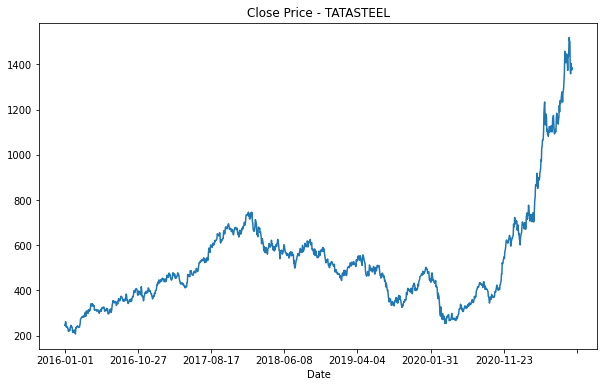

In [7]:
plt.rcParams['figure.figsize'] = (10,6)
df_stock['Close'].plot()
plt.title("Close Price - "+stock_name)

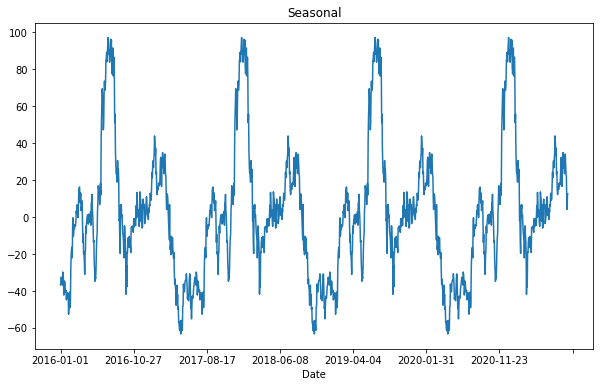

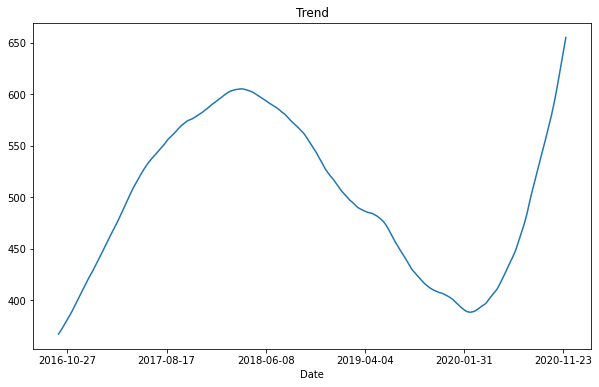

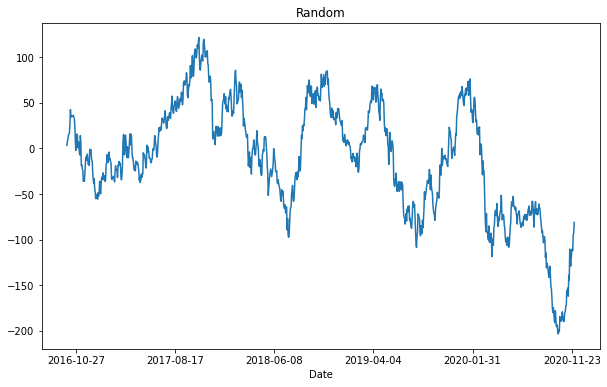

In [8]:
plt.rcParams['figure.figsize'] = (10,6)
decomposition=seasonal_decompose(df_stock['Close'],freq=365)
decomposition.seasonal.plot()
plt.title("Seasonal")
plt.show()
decomposition.trend.plot()
plt.title("Trend")
plt.show()
decomposition.resid.plot()
plt.title("Random")
plt.show()

##*Stationary Check*

In [9]:
Stationary=False
dvalue=0
Stationary_df=df_stock['Close'].copy()
while(Stationary==False):
  dftest = adfuller(Stationary_df.dropna(),autolag='AIC')
  dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
  for key,value in dftest[4].items():
    dfoutput['critical value (%s)'%key]= value
  print(dftest[1])
  if (dftest[1]>0.05):
    Stationary=False
    Stationary_df = Stationary_df - Stationary_df.shift(1)
  else :
    Stationary=True
  dvalue+=1  
print(dfoutput)
print("Differencing Value : ",dvalue)

0.9976107097248165
5.8984610205571605e-06
Test Statistic                   -5.284388
p-value                           0.000006
#lags used                       24.000000
number of observations used    1362.000000
critical value (1%)              -3.435160
critical value (5%)              -2.863664
critical value (10%)             -2.567901
dtype: float64
Differencing Value :  2


##*ACF*

In [10]:
from  statsmodels.tsa.stattools import acf as ACF
ACFOutput = ACF(Stationary_df.dropna(),nlags=20)
print(ACFOutput)

[ 1.00000000e+00  2.75591086e-02 -3.05734137e-02 -6.99730932e-02
  3.81628959e-02  5.91318761e-02 -3.47163594e-02  4.85214620e-02
  1.61590675e-04  7.98217081e-03  1.15709994e-02  1.99515344e-02
  7.34149220e-02  5.87987784e-02 -3.27401303e-02 -3.62638156e-02
 -4.32114802e-02  5.64850311e-02 -5.70614682e-03  2.83447957e-02
  7.97084001e-03]


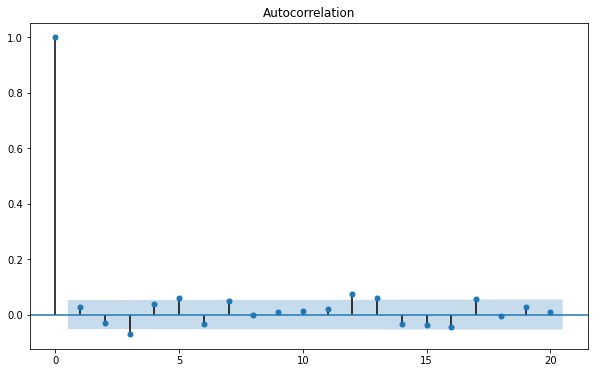

In [11]:
plt.rcParams['figure.figsize'] = (10,6)
pltacf(Stationary_df.dropna(),lags=20)
plt.show()

##*PACF*

In [12]:
PACFOutput = PACF(Stationary_df.dropna(),nlags=20)
print(PACFOutput)

[ 1.00000000e+00  2.75789925e-02 -3.14020483e-02 -6.85074245e-02
  4.13707483e-02  5.34135629e-02 -4.10044197e-02  6.01341204e-02
  1.38126267e-03  8.71316625e-04  1.93343919e-02  1.99052562e-02
  6.75506709e-02  6.34637940e-02 -3.52556203e-02 -2.47573522e-02
 -4.31719554e-02  4.09722058e-02 -1.61593229e-02  2.98586988e-02
  1.04272974e-02]


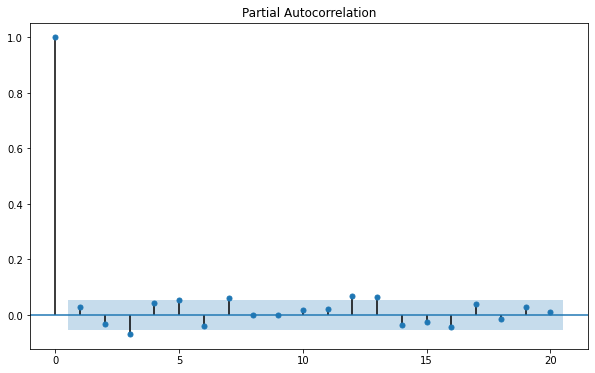

In [13]:
plt.rcParams['figure.figsize'] = (10,6)
pltpacf(Stationary_df.dropna(),lags=20).show()
plt.show()

##*Test and Train Split*

In [14]:
df_stock_train=df_stock.loc['2016-01-01':'2021-07-31']['Close']
df_stock_test=df_stock.loc['2021-07-31':]['Close']

In [15]:
df_stock_train.tail()

Date
2021-07-26    1297.949951
2021-07-27    1330.650024
2021-07-28    1365.000000
2021-07-29    1458.599976
2021-07-30    1434.300049
Name: Close, dtype: float64

In [16]:
df_stock_test.head()

Date
2021-08-02    1410.050049
2021-08-03    1407.199951
2021-08-04    1416.199951
2021-08-05    1446.599976
2021-08-06    1428.849976
Name: Close, dtype: float64

##*Model Fitting*

In [17]:
arima_model=auto_arima(df_stock_train,seasonal=False,max_p=2,max_d=2,max_q=2,start_p=0,start_q=0,d=1)

In [18]:
arima_model

ARIMA(maxiter=50, method='lbfgs', order=(0, 1, 0), out_of_sample_size=0,
      scoring='mse', scoring_args={}, seasonal_order=(0, 0, 0, 0),
      start_params=None, suppress_warnings=True, trend=None,
      with_intercept=True)

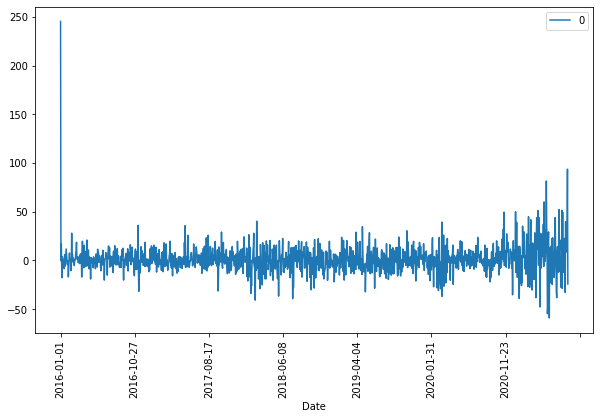

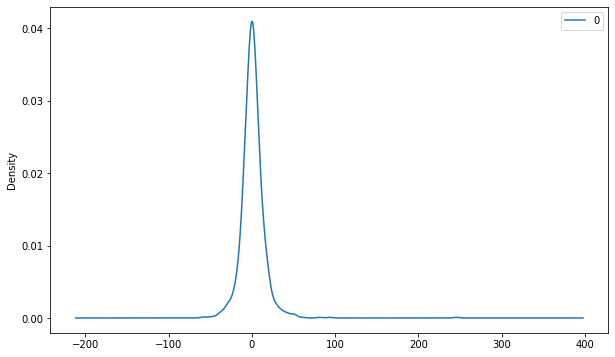

                 0
count  1369.000000
mean      1.047699
std      14.513733
min     -59.199951
25%      -5.764038
50%       0.449951
75%       6.764435
max     245.234406


In [19]:
model = ARIMA(df_stock_train, order=(0,1,0))
model_fit = model.fit()
residuals = pd.DataFrame(model_fit.resid)
plt.rcParams['figure.figsize'] = (10,6)
residuals.plot()
plt.xticks(rotation=90)
plt.show()
residuals.plot(kind='kde')
plt.show()
print(residuals.describe())

##*Forecasting and Testing*

In [20]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values)):
    model = ARIMA(history, order=(0,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)
error = np.sqrt(mean_squared_error(df_stock_test.values, predictions))
print('Test Error Percentage',(error/np.mean(df_stock_test.values))*100)

Test Error Percentage 2.761783079430368


([], <a list of 0 Text major ticklabel objects>)

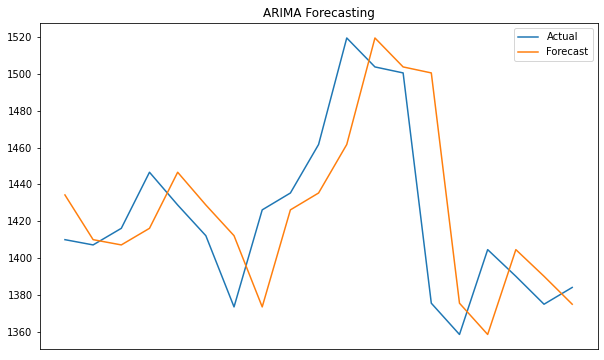

In [21]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(df_stock_test, label='Actual')
plt.plot(predictions, label='Forecast')
plt.title('ARIMA Forecasting')
plt.legend()
plt.xticks([])

##*Forecast for August*

In [22]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values[:14])):
    model = ARIMA(history, order=(0,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)

In [23]:
predictions

[1434.300048828125,
 1410.050048828125,
 1407.199951171875,
 1416.199951171875,
 1446.5999755859375,
 1428.8499755859375,
 1412.199951171875,
 1373.5999755859375,
 1426.199951171875,
 1435.3499755859375,
 1461.6500244140625,
 1519.4000244140625,
 1503.699951171875,
 1500.449951171875]

#**MARS - Multivariate Adaptive Regression Splines**

In [24]:
from pyearth import Earth

In [25]:
df_stock_mars_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:5].copy()
df_stock_mars_test=df_stock.loc['2021-07-31':].iloc[:,:5].copy()

In [26]:
df_stock_mars_train.shape

(1369, 5)

In [27]:
df_stock_mars_test.shape

(19, 5)

In [28]:
df_stock_mars_train.head()

,Open,High,Low,Close,Volume
Date,,,,,
2016-01-01,246.758789,247.616257,241.423462,245.234406,3307909.0
2016-01-04,242.947845,250.760284,241.137650,244.758041,7327733.0
2016-01-05,245.377319,263.336395,245.377319,261.335663,15753483.0
2016-01-06,259.906555,261.621490,253.427948,256.047974,7824538.0
2016-01-07,250.569733,250.855560,236.469238,238.088882,9975180.0


In [29]:
df_stock_mars_test

,Open,High,Low,Close,Volume
Date,,,,,
2021-08-02,1446.000000,1447.000000,1405.500000,1410.050049,9768920.0
2021-08-03,1414.000000,1420.849976,1390.349976,1407.199951,8640560.0
2021-08-04,1420.000000,1448.000000,1405.099976,1416.199951,11289435.0
2021-08-05,1415.300049,1450.000000,1387.500000,1446.599976,16221799.0
2021-08-06,1449.000000,1457.000000,1426.000000,1428.849976,9674025.0
2021-08-09,1434.000000,1443.250000,1405.400024,1412.199951,7859493.0
2021-08-10,1412.000000,1418.000000,1367.199951,1373.599976,8451623.0
2021-08-11,1390.000000,1429.699951,1384.199951,1426.199951,14535357.0
2021-08-12,1436.000000,1444.699951,1416.550049,1435.349976,10943108.0


In [30]:
x_train_mars = df_stock_mars_train.drop(['Close'], axis=1)
y_train_mars = df_stock_mars_train['Close']
x_test_mars = df_stock_mars_test.drop(['Close'], axis=1)
y_test_mars = df_stock_mars_test['Close']

##*Fitting the model*

In [31]:
MARS_model = Earth(max_terms = 600,max_degree=3)
MARS_model_fitted = MARS_model.fit(x_train_mars, y_train_mars)
y_pred_mars = MARS_model_fitted.predict(x_test_mars[:14])

##*Evaluating the model*

In [32]:
MSE = mean_squared_error(y_test_mars[:14], y_pred_mars)
RMSE = np.sqrt(MSE)
RMSE_mean = (RMSE/np.mean(y_test_mars[:14]))*100
print("RMSE Score :", round(RMSE, 2))
print("RMSE/Mean", round(RMSE_mean,1))

RMSE Score : 17.3
RMSE/Mean 1.2


##*Plotting Forecast vs Actual* 

([], <a list of 0 Text major ticklabel objects>)

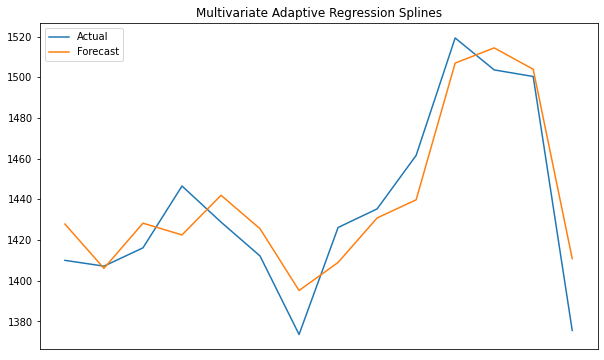

In [33]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(y_test_mars[:14], label='Actual')
plt.plot(y_pred_mars, label='Forecast')
plt.title('Multivariate Adaptive Regression Splines')
plt.legend()
plt.xticks([])

#**VAR - Vector Autoregression**

In [34]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic

In [35]:
df_stock_var = df_stock.loc['2016-01-01':'2021-08-20'].iloc[:,:4].copy()
df_stock_var_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:4].copy()
df_stock_var_test=df_stock.loc['2021-07-31':'2021-08-20'].iloc[:,:4].copy()


In [36]:
df_stock_var_train.shape

(1369, 4)

In [37]:
df_stock_var_test.shape

(14, 4)

In [38]:
df_stock_var.shape

(1383, 4)

##*Plotting the Data*

In [39]:
fig, axes = plt.subplots(nrows=4, ncols=1, dpi=120, figsize=(10,6))
for i, ax in enumerate(axes.flatten()):
    data = df_stock_var[df_stock_var.columns[i]]
    ax.plot(data, linewidth=1)
    # Decorations
    ax.set_title(df_stock_var.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout()

##*Granger Causality Test*

In [40]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag=12
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):    
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

grangers_causation_matrix(df_stock_var, variables = df_stock_var.columns)        

,Open_x,High_x,Low_x,Close_x
Open_y,1.0000,0.0000,0.0,0.0
High_y,0.0000,1.0000,0.0,0.0
Low_y,0.0000,0.0000,1.0,0.0
Close_y,0.0012,0.0129,0.0,1.0


##*Cointegration Test*

In [41]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def cointegration_test(df_stock_var, alpha=0.05): 
    out = coint_johansen(df_stock_var,-1,5)
    d = {'0.90':0, '0.95':1, '0.99':2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1-alpha)]]
    def adjust(val, length= 6): return str(val).ljust(length)

    print('Name   ::  Test Statistic > C(95%)    =>   Significance  \n', '--'*20)
    for col, trace, cvt in zip(df_stock_var.columns, traces, cvts):
        print(adjust(col), ':: ', adjust(round(trace,2), 9), ">", adjust(cvt, 8), ' =>  ' , trace > cvt)

cointegration_test(df_stock_var)

Name   ::  Test Statistic > C(95%)    =>   Significance  
 ----------------------------------------
Open   ::  549.77    > 40.1749   =>   True
High   ::  299.45    > 24.2761   =>   True
Low    ::  87.59     > 12.3212   =>   True
Close  ::  7.74      > 4.1296    =>   True


##*ADF Test*

In [42]:
def adfuller_test(series, signif=0.05, name='', verbose=False):
    """Perform ADFuller to test for Stationarity of given series and print report"""
    r = adfuller(series, autolag='AIC')
    output = {'test_statistic':round(r[0], 4), 'pvalue':round(r[1], 4), 'n_lags':round(r[2], 4), 'n_obs':r[3]}
    p_value = output['pvalue'] 
    def adjust(val, length= 6): return str(val).ljust(length)

    # Print Summary
    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)
    print(f' Null Hypothesis: Data has unit root. Non-Stationary.')
    print(f' Significance Level    = {signif}')
    print(f' Test Statistic        = {output["test_statistic"]}')
    print(f' No. Lags Chosen       = {output["n_lags"]}')

    for key,val in r[4].items():
        print(f' Critical value {adjust(key)} = {round(val, 3)}')

    if p_value <= signif:
        print(f" => P-Value = {p_value}. Rejecting Null Hypothesis.")
        print(f" => Series is Stationary.")
    else:
        print(f" => P-Value = {p_value}. Weak evidence to reject the Null Hypothesis.")
        print(f" => Series is Non-Stationary.")    

In [43]:
# ADF Test on each column
for name, column in df_stock_var_train.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = 3.0771
 No. Lags Chosen       = 0
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 1.0. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = 2.9431
 No. Lags Chosen       = 1
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 1.0. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-S

##*ADF Test on first order differencing*

In [44]:
df_differenced = df_stock_var_train.diff().dropna()

In [45]:
# ADF Test on each column of 1st Differences Dataframe
for name, column in df_differenced.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -3.9306
 No. Lags Chosen       = 24
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0018. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -3.7418
 No. Lags Chosen       = 24
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0036. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    

##*Selecting the number of lags*

In [46]:
model = VAR(df_differenced)
x = model.select_order(maxlags=20)
x.summary()

,AIC,BIC,FPE,HQIC
0,17.28,17.30,3.200e+07,17.29
1,15.53,15.60,5.536e+06,15.56
2,15.03,15.17,3.374e+06,15.08
3,14.73,14.93,2.496e+06,14.81
4,14.61,14.88,2.223e+06,14.71
5,14.50,14.83*,1.985e+06,14.62
6,14.46,14.84,1.901e+06,14.60
7,14.38,14.83,1.767e+06,14.55
8,14.36,14.87,1.725e+06,14.55
9,14.32,14.90,1.663e+06,14.54*


##*Fitting the model*

In [47]:
model_fitted = model.fit(x.aic)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 15, Sep, 2021
Time:                     16:44:11
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    15.4897
Nobs:                     1348.00    HQIC:                   14.7070
Log likelihood:          -16923.6    FPE:                1.52718e+06
AIC:                      14.2384    Det(Omega_mle):     1.20926e+06
--------------------------------------------------------------------
Results for equation Open
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.143221         0.151705            0.944           0.345
L1.Open          -1.036028         0.042618          -24.309           0.000
L1.High           0.044248         0.039721            1.114           0.265


##*Durbin Watson Test*

In [48]:
from statsmodels.stats.stattools import durbin_watson
out = durbin_watson(model_fitted.resid)

for col, val in zip(df_stock_var.columns, out):
    print(col, ':', round(val, 2))

Open : 2.01
High : 2.0
Low : 2.01
Close : 2.0


##*Getting the Forecast*

In [49]:
# Get the lag order
lag_order = model_fitted.k_ar
print(lag_order)

# Input data for forecasting
forecast_input = df_differenced.values[-lag_order:]
forecast_input

20


array([[ -5.90002441, -10.        , -26.25      , -27.55004883],
       [-20.        ,  -5.        ,   5.80004883,  20.84997559],
       [ 12.65002441,  16.19995117,  14.25      ,  10.40002441],
       [  9.29992676,  47.        ,   8.25      ,  51.40002441],
       [ 57.05004883,   5.        ,  22.69995117, -28.90002441],
       [-33.        ,  14.09997559,   6.80004883,  49.59997559],
       [ 59.        ,  14.40002441,  30.34997559, -12.40002441],
       [-13.        , -15.05004883,   4.75      ,   1.80004883],
       [ -6.05004883,   4.25      ,  -4.09997559,  15.94995117],
       [ 14.15002441,  18.10009766,  18.69995117,  11.25      ],
       [ 18.59997559,  15.5       ,  21.35009766,  22.5       ],
       [ -5.69995117,   9.59997559,  -5.35009766, -12.04992676],
       [ 13.        , -18.59997559, -28.69995117, -33.05004883],
       [-23.        ,   5.64990234,  23.        ,  39.65002441],
       [ 30.34997559,  17.55004883,  26.        ,   8.40002441],
       [  9.65002441,  12

In [50]:
nobs = 14
fc = model_fitted.forecast(y=forecast_input, steps=nobs)
df_forecast = pd.DataFrame(fc, index=df_stock_var.index[-nobs:], columns=df_stock_var.columns + '_1d')
df_forecast

,Open_1d,High_1d,Low_1d,Close_1d
Date,,,,
2021-08-02,-14.509541,-7.859959,-16.344431,3.400659
2021-08-03,-4.896778,-6.444634,-3.369113,-3.376767
2021-08-04,8.281258,4.049976,13.001686,7.812810
2021-08-05,-1.079475,10.879948,1.368775,13.224082
2021-08-06,5.950846,6.056307,7.716795,5.446599
2021-08-09,19.429977,16.225751,11.419014,7.826549
2021-08-10,-6.697760,1.699290,-8.170186,-5.458915
2021-08-11,6.945779,-13.345266,2.264181,-10.444925
2021-08-12,-7.554940,-7.892141,-0.209621,2.098159


##*Inverting forecast back to original scale*

In [51]:
def invert_transformation(df_train, df_forecast, first_diff=False):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:        
        if first_diff:
          # Roll back 1st Diff
          df_fc[str(col)+'_forecast'] = df_train[col].iloc[-1] + df_fc[str(col)+'_1d'].cumsum()
    return df_fc

In [52]:
df_results = invert_transformation(df_stock_var_train, df_forecast, first_diff=True)        
df_results.loc[:, ['Open_forecast','High_forecast','Low_forecast','Close_forecast']]

,Open_forecast,High_forecast,Low_forecast,Close_forecast
Date,,,,
2021-08-02,1441.140484,1464.839992,1411.455618,1437.700708
2021-08-03,1436.243706,1458.395358,1408.086505,1434.323941
2021-08-04,1444.524964,1462.445334,1421.088190,1442.136751
2021-08-05,1443.445489,1473.325282,1422.456965,1455.360833
2021-08-06,1449.396335,1479.381589,1430.173760,1460.807433
2021-08-09,1468.826312,1495.607341,1441.592774,1468.633981
2021-08-10,1462.128552,1497.306631,1433.422587,1463.175066
2021-08-11,1469.074331,1483.961365,1435.686768,1452.730141
2021-08-12,1461.519392,1476.069224,1435.477147,1454.828301


##*Plotting Forecast vs Actual*

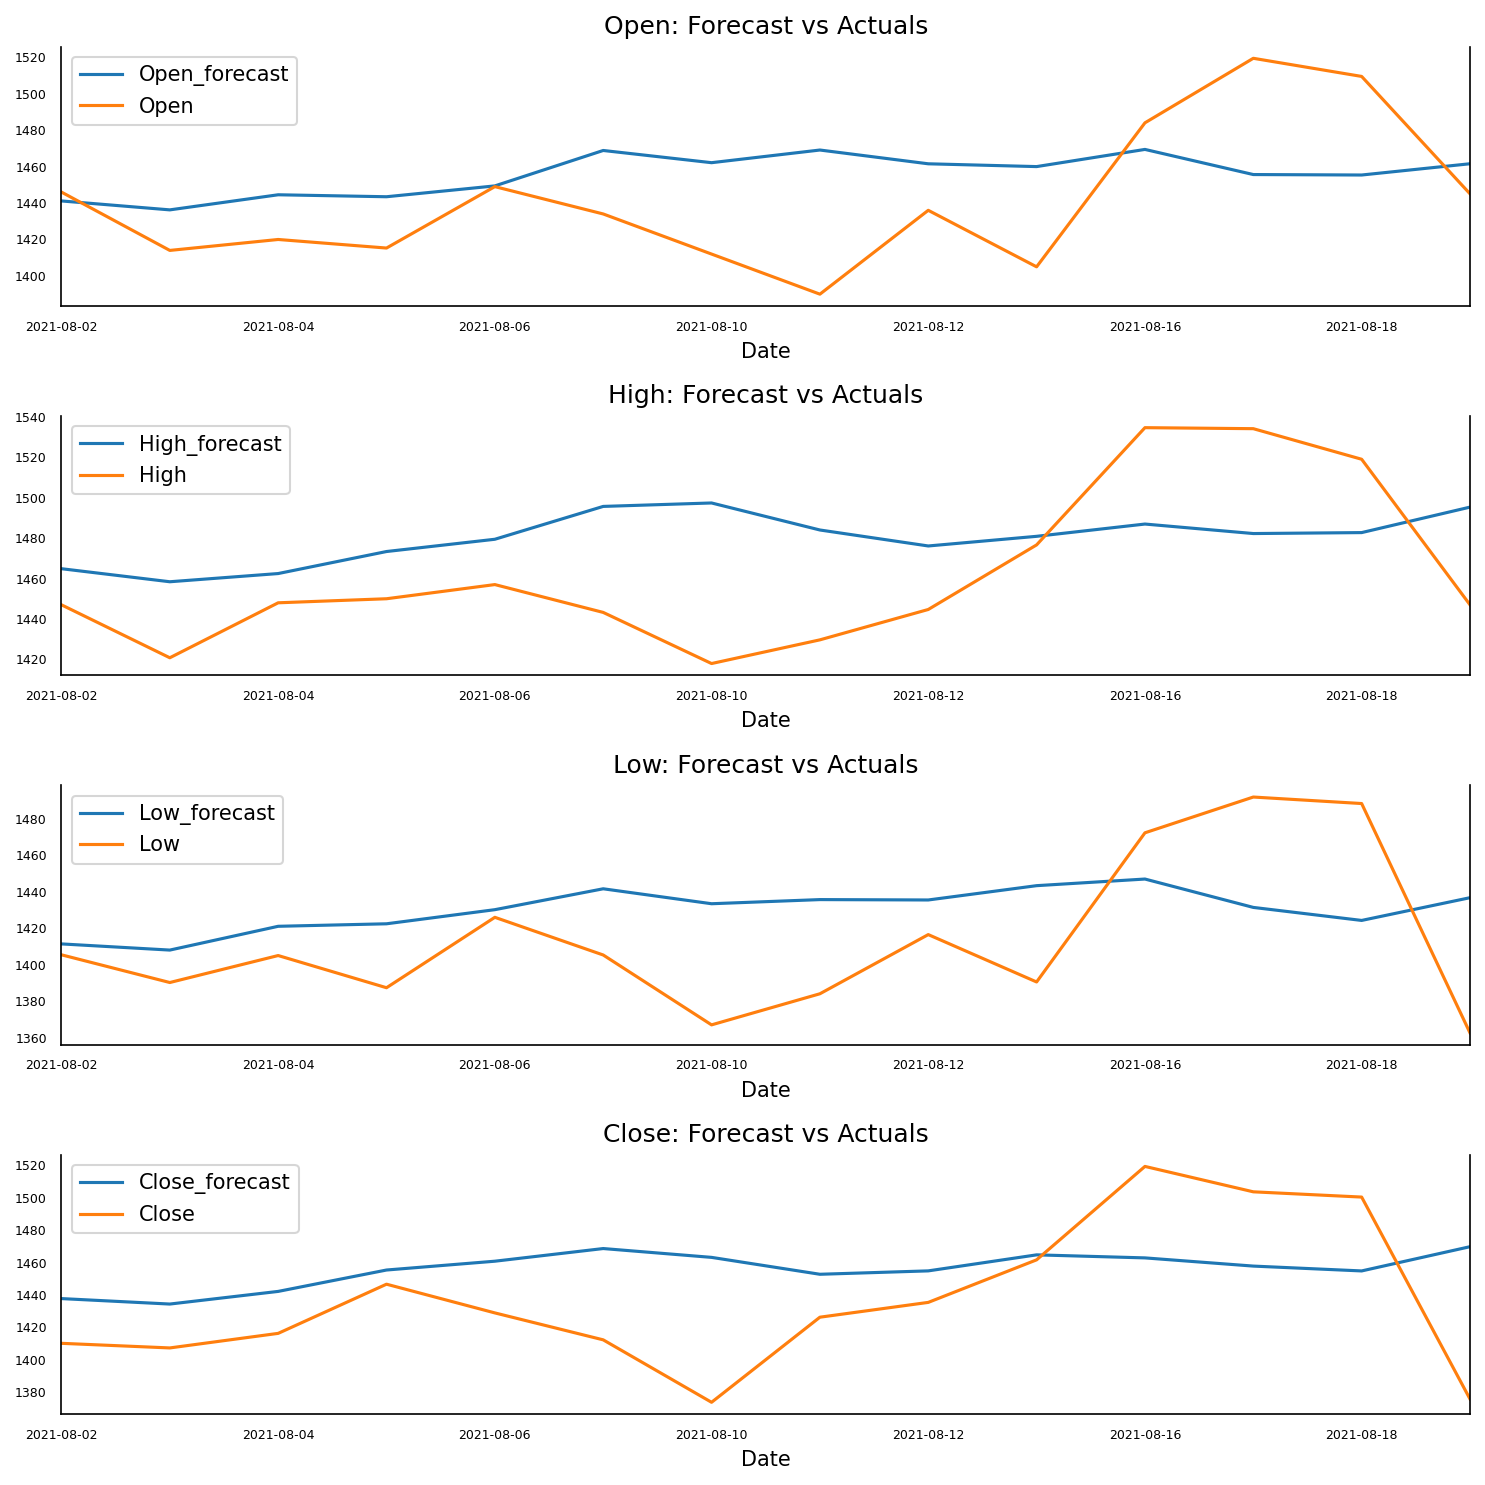

In [53]:
 fig, axes = plt.subplots(nrows=4, ncols=1, dpi=150, figsize=(10,10))
 for i, (col,ax) in enumerate(zip(df_stock_var.columns, axes.flatten())):
   df_results[col+'_forecast'].plot(legend=True, ax=ax).autoscale(axis='x',tight=True)
   df_stock_var_test[col][-nobs:].plot(legend=True, ax=ax);
   ax.set_title(col + ": Forecast vs Actuals")
   ax.xaxis.set_ticks_position('none')
   ax.yaxis.set_ticks_position('none')
   ax.spines["top"].set_alpha(0)
   ax.tick_params(labelsize=6)

plt.tight_layout();

##*Evaluating the model*

In [54]:
from statsmodels.tsa.stattools import acf
def forecast_accuracy(forecast, actual): 
    rmse = np.mean((forecast - actual)**2)**.5  
    rmse_p = (rmse/np.mean(actual))*100
    return({'rmse':rmse,'rmse_mean':rmse_p})

print('Forecast Accuracy of Open')
accuracy_prod = forecast_accuracy(df_results['Open_forecast'].values, df_stock_var_test['Open'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of High')
accuracy_prod = forecast_accuracy(df_results['High_forecast'].values, df_stock_var_test['High'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Low')
accuracy_prod = forecast_accuracy(df_results['Low_forecast'].values, df_stock_var_test['Low'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Close')
accuracy_prod = forecast_accuracy(df_results['Close_forecast'].values, df_stock_var_test['Close'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))



Forecast Accuracy of Open
rmse :  40.5701
rmse_mean :  2.8147

Forecast Accuracy of High
rmse :  41.8742
rmse_mean :  2.864

Forecast Accuracy of Low
rmse :  44.0373
rmse_mean :  3.1148

Forecast Accuracy of Close
rmse :  47.6831
rmse_mean :  3.3184


#**Linear Regression**

In [55]:
df_stock_train_lin=df_stock.loc['2016-01-01':'2021-07-31'].copy()
df_stock_test_lin=df_stock.loc['2021-07-31':].copy()


##*Normalize the data*

In [56]:
from sklearn.preprocessing import MinMaxScaler

In [57]:
scaler = MinMaxScaler()
df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.fit_transform(df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])
df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.transform(df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])

In [58]:
df_stock_train_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,0.032778,0.023592,0.032816,245.234406,0.045311,4,1,1,0.091661,0.026620
2016-01-04,0.029729,0.026080,0.032583,244.758041,0.108248,0,4,1,0.090919,0.057645
2016-01-05,0.031673,0.036029,0.036039,261.335663,0.240167,1,5,1,0.086044,0.133054
2016-01-06,0.043297,0.034672,0.042603,256.047974,0.116026,2,6,1,0.066755,0.044718
2016-01-07,0.035827,0.026155,0.028777,238.088882,0.149698,3,7,1,0.070447,0.100736


In [59]:
df_stock_test_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2021-08-02,0.992279,0.972468,0.981820,1410.050049,0.146468,0,2,8,1.023069,0.345997
2021-08-03,0.966676,0.951780,0.969469,1407.199951,0.128802,1,3,8,1.037370,0.246495
2021-08-04,0.971477,0.973260,0.981494,1416.199951,0.170275,2,4,8,1.041369,0.358661
2021-08-05,0.967716,0.974842,0.967146,1446.599976,0.247499,3,5,8,1.035070,0.535956
2021-08-06,0.994679,0.980380,0.998533,1428.849976,0.144983,4,6,8,1.037309,0.251018


##*Checking for multicollinearity*

In [60]:
from statsmodels.stats.outliers_influence import variance_inflation_factor    

def calculate_vif_(X, thresh=10,verbose=True):
    cols = X.columns
    variables = np.arange(X.shape[1])
    dropped=True
    while dropped:
        dropped=False
        c = X[cols[variables]].values
        vif = [variance_inflation_factor(c, ix) for ix in np.arange(c.shape[1])]
        

        maxloc = vif.index(max(vif))
        if max(vif) > thresh:
            if verbose == True:
                print('dropping \'' + X[cols[variables]].columns[maxloc] + '\' at index: ' + str(maxloc))
            variables = np.delete(variables, maxloc)
            dropped=True
    if verbose == True:
        print('Remaining variables:')
        print(X.columns[variables])
    return X[cols[variables]]

##*Model Generation*

In [61]:
def forward_regression(X, y,
                       threshold_in,
                       verbose=False):
    initial_list = []
    included = list(initial_list)
    while True:
        changed=False
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

        if not changed:
            break

    return included

In [62]:
def backward_regression(X, y,
                           threshold_out,
                           verbose=False):
    included=list(X.columns)
    while True:
        changed=False
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() 
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [63]:
def model_generator(df_train,df_test):
    train_dummy=pd.get_dummies(df_train,columns=['Day of Week','Day of Month','Month'])
    test_dummy = pd.get_dummies(df_test,columns=['Day of Week','Day of Month','Month'])
    for i in [1,2,3,4,5,6,7,9,10,11,12]:
        test_dummy['Month_'+str(i)] = 0
        test_dummy['Month_'+str(i)] = test_dummy['Month_'+str(i)].astype('uint8')
    for i in range(1,32):
      if (i not in df_test['Day of Month'].unique()):
        test_dummy['Day of Month_'+str(i)] = 0
        test_dummy['Day of Month_'+str(i)] = test_dummy['Day of Month_'+str(i)].astype('uint8')   
    X=train_dummy.drop('Close',axis=1)
    y=train_dummy["Close"]
    X_f=calculate_vif_(X.select_dtypes(exclude='uint8'),10,False)
    X_f=pd.concat([X_f,X.iloc[:,6:]],axis=1)
    model=sm.OLS(y,X_f[backward_regression(X_f,y,0.01)],axis=1).fit()
    pred=model.predict(test_dummy[backward_regression(X_f,y,0.01)])
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(test_dummy['Close'], pred))
    rmse_pct= (rmse/np.mean(test_dummy['Close']))*100
    sig_var = model.pvalues.index.tolist()
    return model,sig_var,rmse_pct    

In [64]:
 model,variables,rmse_per = model_generator(df_stock_train_lin,df_stock_test_lin)

In [65]:
print(model.summary2())

                  Results: Ordinary least squares
Model:               OLS              Adj. R-squared:     0.997     
Dependent Variable:  Close            AIC:                10548.9168
Date:                2021-09-15 16:44 BIC:                10642.9099
No. Observations:    1369             Log-Likelihood:     -5256.5   
Df Model:            17               F-statistic:        2.518e+04 
Df Residuals:        1351             Prob (F-statistic): 0.00      
R-squared:           0.997            Scale:              128.33    
--------------------------------------------------------------------
                Coef.   Std.Err.    t     P>|t|    [0.025    0.975] 
--------------------------------------------------------------------
Open          1248.1745   1.9681 634.2098 0.0000 1244.3137 1252.0353
Volume          21.8495   2.6413   8.2722 0.0000   16.6680   27.0310
Day of Week_0  142.9032   0.7669 186.3418 0.0000  141.3988  144.4076
Day of Week_1  143.1981   0.7691 186.1951 0.0000  141

In [66]:
print("Significance Variables :",'\n',*variables,sep='\n')

Significance Variables :


Open
Volume
Day of Week_0
Day of Week_1
Day of Week_2
Day of Week_3
Day of Week_4
Month_1
Month_2
Month_3
Month_4
Month_5
Month_6
Month_7
Month_8
Month_9
Month_10
Month_11
Month_12


In [67]:
print("RMSE Percentage",rmse_per,sep='\n')

RMSE Percentage
2.1940797007602355
